(SurfaceBulk-ADR)=
# Surface-Bulk ADR

We use now the capabilities of the `ADRSolver` class to solve a coupled surface-bulk equation.

We consider as an example the coupled PDE

\begin{align*}
\partial_t u + \nabla\cdot(\vec{b}_1u - d_1 \nabla u) +c_1u^3 = f_1 \text{ on } \Omega \\
\partial_t v + \nabla_\Gamma\cdot(\vec{b}_2v - d_2 \nabla v) + c_2v + u\sin(v^2) = f_2 \text{ on } \partial\Omega 
\end{align*}

The coefficients and differential symbols are as in [bulk-ADR tutorial](Bulk-Adr) and [surface-ADR tutorial](Surface-ADR).

In [1]:
from ngsolve import *
from cosmos.utils.generate_surface_meshes import generate_circle
from cosmos.solvers.simulation import Simulation
from cosmos.solvers.adr import ADRSolver
from cosmos.solvers.tools import gradient
from ngsolve.webgui import Draw
import pandas as pd
import matplotlib.pyplot as plt


mesh, _ = generate_circle(maxh = 0.1)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

u_ex = x*sin(pi*y)*cos(t)
d1 = 2
c1 = sin(x)**2
b1 = CF((2,1))
flux_b1 = (b1*u_ex).Compile()
flux_d1 = (- d1*gradient(u_ex, Id(2))).Compile()
flux1 = flux_b1 + flux_d1
rhs1 = (u_ex.Diff(t) + Trace(gradient(flux1, Id(2))) + c1*u_ex**3).Compile()
dir_d = {'.*': u_ex}

solver.AddSpecie(VorB = VOL,
            rhs = rhs1,
            advection = b1,
            diffusion = d1,
            u0 = u_ex,
            dir_b = dir_d,
            dir_d = dir_d)

v_ex = cos(pi*x)*sin(pi*y)*cos(t)
d2 = 1+t
c2 = cos(x)
b2 = CF((-y,x))
normal = CF((x,y))/Norm(CF((x,y)))
P = Id(2) - OuterProduct(normal, normal)
flux_b2 = (b2*v_ex).Compile()
flux_d2 = (- d2*gradient(v_ex, P)).Compile()
flux2 = flux_b2 + flux_d2
rhs2 = (v_ex.Diff(t) + Trace(gradient(flux2, P)) + c2*v_ex + u_ex*sin(v_ex**2)).Compile()

solver.AddSpecie(VorB = BND,
            rhs = rhs2,
            advection = b2,
            diffusion = d2,
            reaction = c2,
            u0 = v_ex)

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  388
     edges is:  1099
     faces is:  712
     facets is:  1099
     elements is:  712 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  boundary
Regions of co-dimension  2 :
 N.  2 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  True
------------------------------------------------------------ 



As you might have noticed, we did'nt prescribed boundary conditions for $u_ex$, since all the flux is actually constituted by the nonlinear term. We thus now add the nonlinear coupling, which is done through the class `AddNonlinearity` od the `ADRSolver` class. It takes in input:
- `marker0`: the marker for the species I want to add the contribution
- `markers`: the markers for the other quantities involved in the nonlinearity. The respective trial functions will be the arguments of the function given as third argument
- `f`: the function which will describe the non-linearity given as input a list of trial funcitons
- `VorB`: specifying if the integral has to be taken over the boundary or the volume
- `domain`: the name of the domain we want to integrate (It is not substitutive for `VorB`)

In [2]:
def f0(trial):
    return c1*trial[0]**3
solver.AddNonlinearity(marker0 = 0, markers = [0], f = f0, VorB = VOL)

def f1(trial):
    return trial[0]*sin(trial[1]**2)
solver.AddNonlinearity(marker0 = 1, markers = [0, 1], f = f1, VorB = BND)

We can now solve the problem and plot the solutions with respect to the exact ones

In [3]:
solver.ComputeError(ex_sol = [u_ex, v_ex], norm = 'L2', folderpath = './adr_results/', filename = 'surfacebulk_adr_errors')
solver.SaveSolution(folderpath = './adr_results/', filename = 'surfacebulk_adr_errors', n_steps = 100)
    
simulation.run()

print('\nComputed solution')
solver.draw_solution()
print('\nExact solution')
Draw(u_ex, mesh)
Draw(v_ex, mesh)


Initializing...
Initialization successful 
                    N. 1  solvers have been initialized correctly
---------- 
Starting the simulation...


	 Running Simulation...: 100%|█████████████| 10/10 [00:00<00:00, 55.46it/s]

Simulation concluded successfully
----------

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…


Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Let's plot the errors with respect to the exact solutions

    Time   specie0   specie1
0    0.0  0.005053  0.001164
1    0.1  0.006858  0.038654
2    0.2  0.007204  0.057618
3    0.3  0.007117  0.065085
4    0.4  0.006907  0.065154
5    0.5  0.006623  0.060526
6    0.6  0.006273  0.053174
7    0.7  0.005859  0.044574
8    0.8  0.005382  0.035817
9    0.9  0.004846  0.027675
10   1.0  0.004252  0.020650


<function matplotlib.pyplot.show(close=None, block=None)>

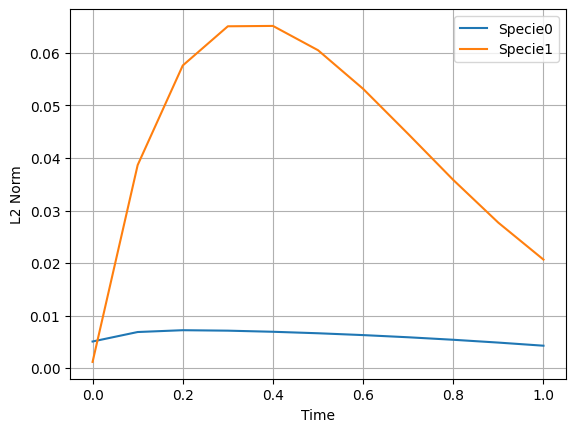

In [4]:
file_path = "./adr_results/surfacebulk_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['specie0'], label = 'Specie0')
plt.plot(df['Time'], df['specie1'], label = 'Specie1')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show

As a further example we can implement the experiment shown in [the SMART code: Example 2](https://rangamanilabucsd.github.io/smart/examples/example2/example2.html) and see if we obtain the same results.

The code is as follows

In [5]:
import time
import numpy as np

mesh, _ = generate_circle(maxh=0.1)

dt = Parameter(0.05)
T = 10
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T)

from cosmos.solvers.adr import ADRSolver
solver = ADRSolver()
simulation.AddSolver(solver)

D_A = 100
D_X = 1
D_B = 1
k_on = 1
k_off = 1


# C_A
neu_d1 = {'.*': CF((0,0))}
solver.AddSpecie(VorB = VOL,
                u0 = 1,
                diffusion = D_A,
                neu_d = neu_d1)

# N_X
solver.AddSpecie(VorB = BND,
                u0 = 1,
                diffusion = D_X)

# N_B
solver.AddSpecie(VorB = BND,
                u0 = 0,
                diffusion = D_B)

def f0(trial):
    return k_on*trial[0]*trial[1] - k_off*trial[2]
solver.AddNonlinearity(marker0 = 0, markers = [0, 1, 2], f = f0, VorB = BND)

def f1(trial):
    return k_on*trial[0]*trial[1] - k_off*trial[2]
solver.AddNonlinearity(marker0 = 1, markers = [0, 1, 2], f = f1, VorB = BND)


def f2(trial):
    return -k_on*trial[0]*trial[1] + k_off*trial[2]
solver.AddNonlinearity(marker0 = 2, markers = [0, 1, 2], f = f2, VorB = BND)

simulation.run()

print('\n')
print('The average value of C_A in the volume is:', Integrate(solver.get_solution()[0], mesh)/pi)
print('The average value of N_X in the volume is:', Integrate(solver.get_solution()[1], mesh, BND)/(2*pi))
print('The average value of N_B in the volume is:', Integrate(solver.get_solution()[2], mesh, BND)/(2*pi))


	 Running Simulation...: 100%|███████████| 200/200 [00:07<00:00, 28.13it/s]



The average value of C_A in the volume is: 0.4131294469390181
The average value of N_X in the volume is: 0.7069922615204904
The average value of N_B in the volume is: 0.29257987091746873
